# Portfolio Optimization using PGD

Minimize:

    f(w) = 0.5 * w^T Σ w

Subject to:

    w_i ≥ 0
    sum(w) = 1

Compare GD vs PGD.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Define Covariance Matrix

In [2]:
np.random.seed(42)

n = 3

M = np.random.randn(n, n)
Sigma = M.T @ M

## Objective Function and Gradient

In [3]:
def f(w):
    return 0.5 * w.T @ Sigma @ w

def grad_f(w):
    return Sigma @ w

Simplex Projection

In [4]:
def project_simplex(y):
    # Algorithm from Duchi et al.
    sorted_y = np.sort(y)[::-1]
    cumulative_sum = np.cumsum(sorted_y)
    
    rho = np.where(sorted_y - (cumulative_sum - 1) / (np.arange(len(y)) + 1) > 0)[0][-1]
    theta = (cumulative_sum[rho] - 1) / (rho + 1)
    
    return np.maximum(y - theta, 0)

## Projected Gradient Descent Algorithm

In [5]:
def projected_gradient_descent(w0, lr, iterations):
    w = w0.copy()
    history = [w.copy()]
    
    for _ in range(iterations):
        y = w - lr * grad_f(w)
        w = project_simplex(y)
        history.append(w.copy())
    
    return np.array(history)

## Run Vanilla Gradient Descent (No Constraint)

In [6]:
def gradient_descent(w0, lr, iterations):
    w = w0.copy()
    history = [w.copy()]
    
    for _ in range(iterations):
        w = w - lr * grad_f(w)
        history.append(w.copy())
    
    return np.array(history)

## Compute Function Values Along Both Trajectories

In [7]:
w0 = np.array([0.7, 0.2, 0.1])
lr = 0.1
iterations = 100

traj_pgd = projected_gradient_descent(w0, lr, iterations)
traj_gd  = gradient_descent(w0, lr, iterations)

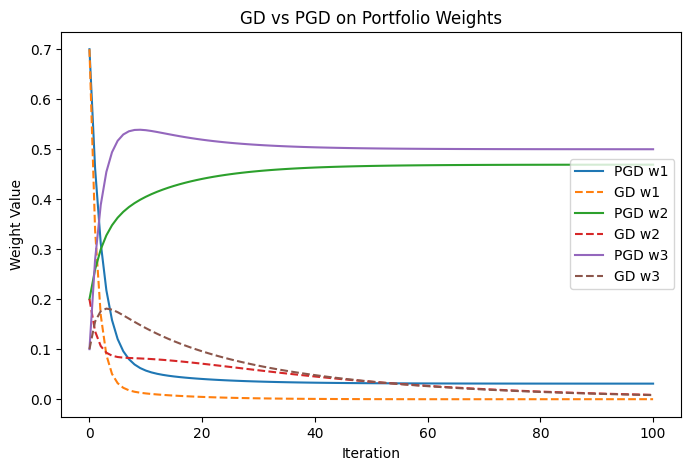

In [8]:
plt.figure(figsize=(8,5))

for i in range(n):
    plt.plot(traj_pgd[:,i], label=f"PGD w{i+1}")
    plt.plot(traj_gd[:,i], '--', label=f"GD w{i+1}")

plt.title("GD vs PGD on Portfolio Weights")
plt.xlabel("Iteration")
plt.ylabel("Weight Value")
plt.legend()
plt.show()

In [9]:
import plotly.graph_objects as go

fig = go.Figure()

# PGD traces
for i in range(n):
    fig.add_trace(go.Scatter(
        y=traj_pgd[:, i],
        mode='lines',
        name=f'PGD w{i+1}'
    ))

# GD traces
for i in range(n):
    fig.add_trace(go.Scatter(
        y=traj_gd[:, i],
        mode='lines',
        line=dict(dash='dash'),
        name=f'GD w{i+1}'
    ))

# Compute full range from both trajectories
y_min = min(traj_pgd.min(), traj_gd.min())
y_max = max(traj_pgd.max(), traj_gd.max())

fig.update_layout(
    title="GD vs PGD on Portfolio Weights",
    xaxis_title="Iteration",
    yaxis_title="Weight Value",
    template="plotly_white",
    hovermode="x unified",
    yaxis=dict(range=[y_min * 1.1, y_max * 1.1])
)

fig.show()

In [10]:
print("Min GD weight:", traj_gd.min())
print("Min PGD weight:", traj_pgd.min())

Min GD weight: -0.00016361392045376378
Min PGD weight: 0.031029210888664838
